In [2]:
!pip install torch torchvision pandas tqdm scikit-learn matplotlib seaborn torchmetrics


  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached lightning_utilities-0.15.2-py3-none-any.whl.metadata (5.7 kB)
Using cached torchmetrics-1.8.2-py3-none-any.whl (983 kB)
Using cached lightning_utilities-0.15.2-py3-none-any.whl (29 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchmetrics] [torchmetrics]


In [ ]:
import torch, torchvision
print("torch:", torch.__version__, torch.__file__)
print("torchvision:", torchvision.__version__, torchvision.__file__)


torch: 2.10.0+cu128 /home/na1488tr-s/.local/lib/python3.10/site-packages/torch/__init__.py
torchvision: 0.25.0+cu128 /home/na1488tr-s/.local/lib/python3.10/site-packages/torchvision/__init__.py


In [1]:
import sys
print(sys.executable)


/home/na1488tr-s/Bachelor_Project_Statistics/.venv/bin/python


In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy
#from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset

from models.basemodel import CNNWithSizeMLP

print("All libraries imported successfully!")

All libraries imported successfully!


## Preparing data

In [10]:
train_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain'
test_dir = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest'
test_excel_path = '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Size_features/size_data.xlsx'


def collect_filenames(root_dir):
    """
    Collect all image filenames recursively from root_dir.
    Returns list of filenames (without path).
    """
    filenames = []
    for species in os.listdir(root_dir):
        species_dir = os.path.join(root_dir, species)
        if not os.path.isdir(species_dir):
            continue

        for fn in os.listdir(species_dir):
            if fn.lower().endswith(('.png', '.jpg', '.jpeg')):
                filenames.append(fn)
    return filenames


# Collect filenames
train_files = collect_filenames(train_dir)
test_files  = collect_filenames(test_dir)

print(f"Train images: {len(train_files)}")
print(f"Test images: {len(test_files)}")

Train images: 8078
Test images: 1922


In [11]:
# Convert to pandas DataFrame
train_df = pd.DataFrame({'filename': train_files})
test_df  = pd.DataFrame({'filename': test_files})

# Extract flower ID (before underscore)
train_df['flower_id'] = train_df['filename'].str.split(' ').str[-1].str.split('_').str[0]
test_df['flower_id']  = test_df['filename'].str.split(' ').str[-1].str.split('_').str[0]

print(train_df.head())

                             filename flower_id
0  Tussilago farfara 1000328_3192.png   1000328
1  Tussilago farfara 1005387_1866.png   1005387
2  Tussilago farfara 1001625_1653.png   1001625
3  Tussilago farfara 1000328_1189.png   1000328
4   Tussilago farfara 1004811_656.png   1004811


In [14]:
train_flower_ids = set(train_df['flower_id'])
test_flower_ids  = set(test_df['flower_id'])

overlap = train_flower_ids.intersection(test_flower_ids)

print(f"Unique flower IDs in train: {len(train_flower_ids)}")
print(f"Unique flower IDs in test: {len(test_flower_ids)}")
print(f"Overlap in flower IDs: {len(overlap)}")

print(f"\n Overlapping flower IDs: {overlap}")


Unique flower IDs in train: 49
Unique flower IDs in test: 11
Overlap in flower IDs: 0

 Overlapping flower IDs: set()


In [ ]:

size_lookup, species_mean_lookup, global_mean = lookup_size_from_excel(test_excel_path)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
#train_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor
#test_tf = T.Compose([T.ToTensor()]) # converts PIL → Tensor

train_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = PollenFolderWithSizeDataset(img_dir=train_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=train_tf)
test_dataset = PollenFolderWithSizeDataset(img_dir=test_dir, class_to_idx=class_to_idx, size_lookup=size_lookup, species_mean_lookup=species_mean_lookup, transform=test_tf)




Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 7922 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: False
Total scanned images: 8078
   Final dataset size:   7922
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 
Dropped missing:      156


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.


In [20]:
train_counts = Counter([train_dataset[i][2].item() for i in range(len(train_dataset))])
test_counts = Counter([test_dataset[i][2].item() for i in range(len(test_dataset))])


In [21]:
print("Training set class distribution:")
for k in sorted(train_counts):
    print(k, idx_to_class[int(k)], train_counts[k])

Training set class distribution:
0 Bellis perennis 856
1 Brassica napus 795
2 Capsella bursa-pastoris 817
3 Cichorium intybus 870
4 Crepis capillaris 799
5 Hieracium umbellatum 735
6 Hypochaeris radicata 717
7 Sonchus arvensis 666
8 Tragopogon pratensis 834
9 Tussilago farfara 833


In [22]:

print("\nTest set class distribution:")
for k in sorted(test_counts):
    print(k, idx_to_class[int(k)], test_counts[k])


Test set class distribution:
0 Bellis perennis 142
1 Brassica napus 200
2 Capsella bursa-pastoris 183
3 Cichorium intybus 130
4 Crepis capillaris 200
5 Hieracium umbellatum 200
6 Hypochaeris radicata 200
7 Sonchus arvensis 334
8 Tragopogon pratensis 166
9 Tussilago farfara 167


In [23]:
def train_epoch(model, loader, device, optimizer, loss_fn):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for imgs, sizes, labels in tqdm(loader):
        imgs = imgs.to(device)
        sizes = sizes.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, sizes)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def eval_epoch(model, loader, device, recall_metric, accuracy_metric, loss_fn=None):
    model.eval()
    
    recall_metric.reset()
    accuracy_metric.reset()
    
    total_loss = 0
    batches = 0
    
    with torch.no_grad():
        for imgs, sizes, labels in loader:
            imgs = imgs.to(device)
            sizes = sizes.to(device)
            labels = labels.to(device)

            outputs = model(imgs, sizes)
            preds = outputs.argmax(dim=1)
            
            recall_metric.update(preds, labels)
            accuracy_metric.update(preds, labels)
            
            if loss_fn is not None:
                loss = loss_fn(outputs, labels)
                total_loss += loss.item()
                batches += 1
            
    recall_per_class = recall_metric.compute().cpu() # tensor of shape (num_classes,)
    accuracy = accuracy_metric.compute().cpu().item() # scalar
    val_loss = total_loss / batches if loss_fn is not None else None
    
    return recall_per_class, accuracy, val_loss

In [24]:
# Validation split (80% train, 20% val)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

# For reproducibility, set a random seed
generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=generator)

print(f"Train subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")

Train subset size: 6337
Validation subset size: 1585


## Base Model (Erik's)

In [25]:
from os import access

from sympy import Mul

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
model = CNNWithSizeMLP(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  




Using device: cuda


In [ ]:
# HYPERPARAMETERS
BATCH_SIZE = 32
EPOCHS_NUM = 50

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0   # initialize before loop
print_every = 5

for epoch in range(1, EPOCHS_NUM + 1):
    train_loss, train_acc = train_epoch(model, train_loader, device, optimizer, loss_fn)
    val_recall_per_class, val_acc, val_loss = eval_epoch(model, val_loader, device, recall_metric, accuracy_metric, loss_fn)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}: train loss {train_loss:.4f}, train accuracy {train_acc:.4f} | val loss {val_loss:.4f}, val accuracy {val_acc:.4f}")
    if epoch == 1 or epoch % print_every == 0:
        print(f"Val Recall per class: {val_recall_per_class}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Saved new best model with val accuracy {best_val_acc:.4f}! And recall per class: {val_recall_per_class}.")

100%|██████████| 100/100 [00:18<00:00,  5.48it/s]


Epoch 1: train loss 0.2579, train accuracy 0.9208 | val loss 1.2956, val accuracy 0.6877
Val Recall per class: tensor([0.2182, 0.5249, 1.0000, 0.5707, 0.8944, 0.6519, 0.8686, 0.9776, 1.0000,
        0.3293])
Saved new best model!


100%|██████████| 100/100 [00:18<00:00,  5.43it/s]


Epoch 2: train loss 0.1190, train accuracy 0.9738 | val loss 0.3347, val accuracy 0.9035
Saved new best model!


100%|██████████| 100/100 [00:18<00:00,  5.55it/s]


...

Epoch 33: train loss 0.1088, train accuracy 0.9894 | val loss 0.2861, val accuracy 0.9293


100%|██████████| 100/100 [00:18<00:00,  5.52it/s]


Epoch 34: train loss 0.0802, train accuracy 0.9975 | val loss 0.0415, val accuracy 0.9893


100%|██████████| 100/100 [00:17<00:00,  5.59it/s]


Epoch 35: train loss 0.1214, train accuracy 0.9872 | val loss 0.1942, val accuracy 0.9388
Val Recall per class: tensor([0.6606, 1.0000, 0.8903, 1.0000, 0.9859, 0.9873, 0.9854, 0.8657, 1.0000,
        1.0000])


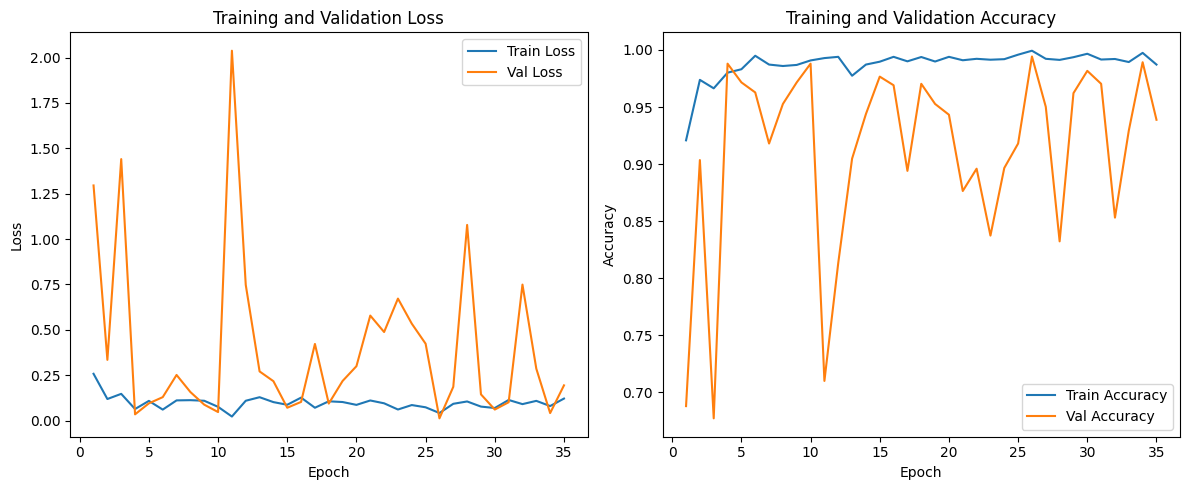

In [27]:
epochs = range(1, EPOCHS_NUM + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, history["train_loss"], label="Train Loss")
ax[0].plot(epochs, history["val_loss"], label="Val Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training and Validation Loss")
ax[0].legend()
ax[1].plot(epochs, history["train_acc"], label="Train Accuracy")
ax[1].plot(epochs, history["val_acc"], label="Val Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training and Validation Accuracy")
ax[1].legend()
plt.tight_layout()
plt.show()

In [31]:
print("\nTraining complete.")
print("Loading best model for final test evaluation...")

model.load_state_dict(torch.load("best_model.pth"))

test_recall_per_class, test_acc, _ = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, None)

print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Recall per class: {test_recall_per_class}")


Training complete.
Loading best model for final test evaluation...

Final Test Accuracy: 0.7232
Final Test Recall per class: tensor([0.1268, 1.0000, 1.0000, 1.0000, 0.0100, 0.9150, 0.4800, 0.7635, 0.9398,
        1.0000])


## Data Augumentation